Функция, которая рисует синусоиду заданой чистоты

In [8]:
import plotly as py
import plotly.graph_objects as go 
import numpy as np
from plotly.subplots import make_subplots

def sin(interval_end, amplitude, frequency):
    t = np.linspace(0, interval_end, 30)
    y = amplitude * np.sin(2 * np.pi * frequency * t)

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=t, 
        y=y, 
        mode='lines', 
        name=f'Синусоида: f={frequency} Гц, A={amplitude}'
    ))
    fig.show()

sin(1, 2, 2)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
import numpy as np
import plotly
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots

SAMPLE_RATE = 44100  # Гц
DURATION = 5  # Секунды
AMPLITUDE = 3

def generate_sine_wave(freq, sample_rate, duration, amplitude = 1):
    x = np.linspace(0, duration, sample_rate*duration, endpoint=False)
    frequencies = x * freq
    # 2pi для преобразования в радианы
    y = amplitude *np.sin((2 * np.pi) * frequencies)
    return x, y

# Генерируем волну с частотой 2 Гц, которая длится 5 секунд
x, y = generate_sine_wave(2, SAMPLE_RATE, DURATION, AMPLITUDE)
px.scatter(x=x, y=y).show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [3]:


_, nice_tone = generate_sine_wave(400, SAMPLE_RATE, DURATION)
_, noise_tone = generate_sine_wave(4000, SAMPLE_RATE, DURATION)

noise_tone = noise_tone * 0.3
mixed_tone = nice_tone + noise_tone

In [ ]:
normalized_tone = np.int16((mixed_tone / mixed_tone.max()) * 32767)

fig = go.Figure()
fig.add_trace(go.Scatter(y=normalized_tone[:1000], mode='lines'))
fig.show()

TypeError: scatter() got an unexpected keyword argument 'mode'

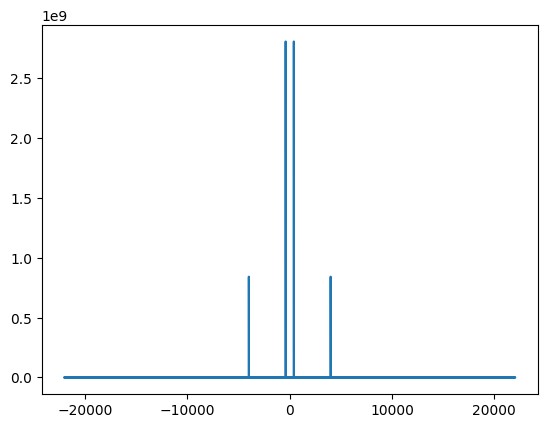

In [ ]:
from scipy.fft import fft, fftfreq

# число точек в normalized_tone
N = SAMPLE_RATE * DURATION

yf = fft(normalized_tone)
xf = fftfreq(N, 1 / SAMPLE_RATE)

px.scatter(x=xf, y=np.abs(yf)).show()

In [12]:
import pandas

data = pandas.read_csv("../lab_1/1_w.csv", sep=';', encoding='cp1251')
data = data[~(data['Ускорение по оси X'] == 0)]

data['azimut_a'] = data.apply(lambda x: np.arctan(x['Ускорение по оси Z']/x['Ускорение по оси X']), axis=1)
data['s_a'] = data.apply(lambda x: np.sqrt(x['Ускорение по оси Z']**2+x['Ускорение по оси X']**2)*9.81*9.81, axis=1)
data['s_v'] = data.apply(lambda x: x['Скорость'], axis=1)

display(data[['len', 'Скорость', 'Широта', 'Долгота', 'Высота', 'путь', 'Ускорение по оси X', 'Ускорение по оси Y', 'Ускорение по оси Z', 'azimut', 'azimut_a', 's_a', 's_v']])

,len,Скорость,Широта,Долгота,Высота,путь,Ускорение по оси X,Ускорение по оси Y,Ускорение по оси Z,azimut,azimut_a,s_a,s_v
0,0.0,8.0,60.646058,59.714841,334.00,0.000000,0.008057,1.048584,0.183228,-0.675910,1.526854,17.650142,8.0
1,2.0,8.0,60.646048,59.714865,333.90,1.690442,0.077881,1.008423,-0.045288,-1.023756,-0.526709,8.670034,8.0
2,4.0,9.0,60.646032,59.714886,334.00,2.150653,0.008057,1.097900,0.059692,-0.932699,1.436638,5.796650,9.0
3,7.0,9.0,60.646012,59.714915,334.30,2.702545,0.042114,0.956177,0.032104,-0.877463,0.651339,5.096253,9.0
4,9.0,9.0,60.645999,59.714938,334.10,1.978095,0.017822,0.995605,0.047729,-0.827510,1.213428,4.903074,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,4026.0,4.0,60.661608,59.733798,455.90,0.939346,0.074951,1.028809,0.081665,1.421164,0.828240,10.667396,4.0
671,4027.0,3.0,60.661617,59.733801,456.00,0.975688,0.073975,1.014160,0.085327,1.325634,0.856542,10.867849,3.0
672,4028.0,1.0,60.661625,59.733805,456.60,0.656499,0.003540,1.037354,0.111328,1.039998,1.539009,10.719200,1.0
673,4029.0,3.0,60.661633,59.733815,456.25,0.735362,0.008789,1.000671,0.105774,0.953742,1.487894,10.214351,3.0


3 ЛР: Обработать 3 процесса 
навигация 
определение через скорость спидометра, 
обработка данных по ускорению

Сделаем таблицу:
len, путь, скорость, v delta t, широта долгота ускорения по всем осям и азимут